Preprocessing & Feature Engineering

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer

bdi = pd.read_csv("../data/raw/bdi.csv")
mh = pd.read_csv("../data/raw/mental_health.csv")

df = pd.merge(bdi, mh, on="subject_id", how="inner")
df.head()

print(bdi.shape, mh.shape, df.shape)
df.head()

(4810, 29) (4810, 10) (4810, 38)


,subject_id,screen_normal_day_1to6,screen_weekday_1to6,screen_weekend_1to6,sqi_fall_asleep_1to6,sqi_repeated_awake_1to6,sqi_disturbed_1to6,sqi_early_awake_1to6,bdi_item_01,bdi_item_02,...,bdi_item_21,sex,screen_time_index,est_leisure_screen_hours,sleep_quality_index,avg_sleep_hours,midsleep_weekend_hours,social_jetlag_hours,bdi_total,depressed
0,1,2,3,5,1,3,2,3,0,1,...,0,Boy,3.333,4.64,2.25,8.36,4.58,1.92,6,0
1,2,3,3,4,4,2,3,1,1,0,...,0,Girl,3.333,4.07,2.50,7.31,5.42,2.25,7,0
2,3,3,3,4,3,1,3,1,1,1,...,1,Boy,3.333,4.07,2.00,8.75,5.50,2.62,27,1
3,4,4,4,5,2,1,2,1,0,1,...,0,Boy,4.333,6.07,1.50,8.17,6.62,3.96,22,1
4,5,3,1,1,2,2,4,2,0,0,...,0,Boy,1.667,0.50,2.50,8.88,4.12,1.79,3,0


---
## 1. Inspect the dataset

In [3]:
bdi = pd.read_csv("../data/raw/bdi.csv")
mh = pd.read_csv("../data/raw/mental_health.csv")

print("BDI rows:", len(bdi))
print("Mental health rows:", len(mh))

ids_bdi = set(bdi["subject_id"])
ids_mh = set(mh["subject_id"])

print("Unique IDs in BDI:", len(ids_bdi))
print("Unique IDs in Mental_health:", len(ids_mh))
print("Same set of IDs:", ids_bdi == ids_mh)
print("IDs only in BDI:", ids_bdi - ids_mh)
print("IDs only in Mental_health:", ids_mh - ids_bdi)

BDI rows: 4810
Mental health rows: 4810
Unique IDs in BDI: 4810
Unique IDs in Mental_health: 4810
Same set of IDs: True
IDs only in BDI: set()
IDs only in Mental_health: set()


In [4]:
missing = df.isna().sum()
print(pd.DataFrame({
    "missing": missing,
    "percent": (missing / len(df) * 100).round(1)
}).sort_values("missing", ascending=False))

print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate subject_ids:", df["subject_id"].duplicated().sum())

print("\n", df.describe().T[["min", "max", "mean", "std"]])

                          missing  percent
subject_id                      0      0.0
screen_normal_day_1to6          0      0.0
screen_weekday_1to6             0      0.0
screen_weekend_1to6             0      0.0
sqi_fall_asleep_1to6            0      0.0
sqi_repeated_awake_1to6         0      0.0
sqi_disturbed_1to6              0      0.0
sqi_early_awake_1to6            0      0.0
bdi_item_01                     0      0.0
bdi_item_02                     0      0.0
bdi_item_03                     0      0.0
bdi_item_04                     0      0.0
bdi_item_05                     0      0.0
bdi_item_06                     0      0.0
bdi_item_07                     0      0.0
bdi_item_08                     0      0.0
bdi_item_09                     0      0.0
bdi_item_10                     0      0.0
bdi_item_11                     0      0.0
bdi_item_12                     0      0.0
bdi_item_13                     0      0.0
bdi_item_14                     0      0.0
bdi_item_15

In [5]:
# Categorical counts — include missing values
# Hint: df[col].value_counts(dropna=False)

for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


sex
sex
Boy     2446
Girl    2364
Name: count, dtype: int64


/var/folders/9m/cypyns911b34vcxt_dw_wqjm0000gp/T/ipykernel_15982/3825091459.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [6]:
df["sex"].value_counts(dropna=False)

sex
Boy     2446
Girl    2364
Name: count, dtype: int64

---
## 2. Row-wise cleaning (before the split)

In [7]:
df_clean = df.copy().drop_duplicates()

# Standardise categorical labels with fixed, row-wise rules.
sex_map = {
    "boy": "Boy", "male": "Boy", "m": "Boy",
    "girl": "Girl", "female": "Girl", "f": "Girl",
}

df_clean["sex"] = (
    df_clean["sex"].str.strip().str.lower().map(sex_map)
)

# These values are fairly impossible rather than merely unusual.
bdi_item_cols = [c for c in df_clean.columns if c.startswith("bdi_item_")]
for col in bdi_item_cols:
    df_clean.loc[~df_clean[col].between(0, 3), col] = np.nan

df_clean.loc[~df_clean["bdi_total"].between(0, 63), "bdi_total"] = np.nan
df_clean.loc[~df_clean["depressed"].isin([0, 1]), "depressed"] = np.nan

scale_1to6_cols = ["screen_normal_day_1to6", "screen_weekday_1to6", "screen_weekend_1to6",
                   "sqi_fall_asleep_1to6", "sqi_repeated_awake_1to6",
                   "sqi_disturbed_1to6", "sqi_early_awake_1to6",
                   "screen_time_index", "sleep_quality_index"]
for col in scale_1to6_cols:
    df_clean.loc[~df_clean[col].between(1, 6), col] = np.nan

df_clean.loc[~df_clean["avg_sleep_hours"].between(0, 24), "avg_sleep_hours"] = np.nan
df_clean.loc[~df_clean["midsleep_weekend_hours"].between(0, 24), "midsleep_weekend_hours"] = np.nan

print("Rows after removing duplicates:", len(df_clean))
print("\nStandardised sex labels:")
print(df_clean["sex"].value_counts(dropna=False))

print("\nImpossible values replaced with NaN:")
print(df_clean.isna().sum()[df_clean.isna().sum() > 0])

Rows after removing duplicates: 4810

Standardised sex labels:
sex
Boy     2446
Girl    2364
Name: count, dtype: int64

Impossible values replaced with NaN:
Series([], dtype: int64)


**Checkpoint.** Run this cell. If an assertion fails, go back and fix section 2.

In [ ]:
assert df_clean.duplicated().sum() == 0, "There are still duplicate rows"
assert set(df_clean["sex"].dropna()) <= {"Boy", "Girl"}, "Sex labels not standardised"

bdi_item_cols = [c for c in df_clean.columns if c.startswith("bdi_item_")]
for col in bdi_item_cols:
    assert df_clean[col].dropna().between(0, 3).all(), f"Impossible values remain in {col}"

assert df_clean["bdi_total"].dropna().between(0, 63).all(), "Impossible bdi_total values remain"
assert df_clean["depressed"].dropna().isin([0, 1]).all(), "Impossible depressed values remain"

scale_1to6_cols = ["screen_normal_day_1to6", "screen_weekday_1to6", "screen_weekend_1to6",
                   "sqi_fall_asleep_1to6", "sqi_repeated_awake_1to6",
                   "sqi_disturbed_1to6", "sqi_early_awake_1to6",
                   "screen_time_index", "sleep_quality_index"]
for col in scale_1to6_cols:
    assert df_clean[col].dropna().between(1, 6).all(), f"Impossible values remain in {col}"

assert df_clean["avg_sleep_hours"].dropna().between(0, 24).all(), "Impossible avg_sleep_hours remain"
assert df_clean["midsleep_weekend_hours"].dropna().between(0, 24).all(), "Impossible midsleep_weekend_hours remain"

print("Section 2 checks passed:", df_clean.shape)

Section 2 checks passed: (4810, 38)


---
## 3. Target and features — check for target leakage

Given the research question, depressed is the target, and bdi_total plus all 21 bdi_item_* columns are unambiguous leakage — depressed is literally derived by thresholding bdi_total, so including any of them as predictors would let the model "cheat" by seeing the answer rather than predicting it from screen time and sleep.

The question also tells us something else: The features should be only screen time and sleep-quality variables, not sex. Since the research question specifically asks whether screen time and sleep-quality responses can predict the outcome, sex isn't part of what the research question is testing — including it without justification would answer a different, broader question than the one that have been stated.

In [9]:
target = "depressed"

screen_time_cols = [
    "screen_normal_day_1to6", "screen_weekday_1to6", "screen_weekend_1to6",
    "screen_time_index", "est_leisure_screen_hours"
]
sleep_quality_cols = [
    "sqi_fall_asleep_1to6", "sqi_repeated_awake_1to6",
    "sqi_disturbed_1to6", "sqi_early_awake_1to6",
    "sleep_quality_index", "avg_sleep_hours",
    "midsleep_weekend_hours", "social_jetlag_hours"
]

feature_cols = screen_time_cols + sleep_quality_cols

X = df_clean[feature_cols]
y = df_clean[target]

print("Target:", target)
print("Features:", feature_cols)
print("\nExcluded as leaky: bdi_total, all bdi_item_* columns")
print("Excluded as out of scope for this research question: subject_id, sex")

print("\nClass balance:")
print(y.value_counts(normalize=True))

Target: depressed
Features: ['screen_normal_day_1to6', 'screen_weekday_1to6', 'screen_weekend_1to6', 'screen_time_index', 'est_leisure_screen_hours', 'sqi_fall_asleep_1to6', 'sqi_repeated_awake_1to6', 'sqi_disturbed_1to6', 'sqi_early_awake_1to6', 'sleep_quality_index', 'avg_sleep_hours', 'midsleep_weekend_hours', 'social_jetlag_hours']

Excluded as leaky: bdi_total, all bdi_item_* columns
Excluded as out of scope for this research question: subject_id, sex

Class balance:
depressed
0.0    0.836383
1.0    0.163617
Name: proportion, dtype: float64


---
## 4. Train / test split

From here on, **anything that learns from the data is fitted on `X_train` only** and then applied to `X_test`.

The test set is looked at **once, at the end**.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain class balance:")
print(y_train.value_counts(normalize=True))
print("\nTest class balance:")
print(y_test.value_counts(normalize=True))

Train shape: (3848, 13)
Test shape: (962, 13)

Train class balance:
depressed
0.0    0.836279
1.0    0.163721
Name: proportion, dtype: float64

Test class balance:
depressed
0.0    0.836798
1.0    0.163202
Name: proportion, dtype: float64


---
## Train/test split summary

The dataset (4,810 adolescents) was split into a training set (3,848 rows, 80%) and a test set (962 rows, 20%) using a stratified random split (`random_state=42`), so the model can be evaluated on data it never saw during training.

Both feature sets contain 13 predictors: five screen-time variables (daily, weekday, weekend screen time, a composite screen-time index, and estimated leisure screen hours) and eight sleep-quality variables (four sleep-quality-index components, a composite sleep-quality index, average sleep hours, weekend mid-sleep time, and social jetlag).

The target variable, `depressed`, is imbalanced: approximately 16.4% of adolescents cross the clinical threshold for at least mild depression, while the remaining 83.6% do not. Stratified sampling was used to preserve this ratio in both the training set (16.4%) and test set (16.3%), ensuring the model is trained and evaluated on comparable class distributions.

This imbalance has an important implication for model evaluation later on: a naive classifier that always predicts "not depressed" would already achieve roughly 84% accuracy without learning anything meaningful. Accuracy alone will therefore be a misleading metric — precision, recall, and F1-score for the depressed class should be reported alongside it.

---
## 5. Missing values

In [11]:
print("Missing values in the training data:")
print(X_train.isna().sum().sort_values(ascending=False))

# Learn medians from TRAINING data only — the test set must not influence this.
medians = X_train.median()

# Reuse the training medians in both datasets.
X_train = X_train.fillna(medians)
X_test = X_test.fillna(medians)

print("\nMissing values after imputation:")
print(X_train.isna().sum().sum(), "in train;", X_test.isna().sum().sum(), "in test")

Missing values in the training data:
screen_normal_day_1to6      0
screen_weekday_1to6         0
screen_weekend_1to6         0
screen_time_index           0
est_leisure_screen_hours    0
sqi_fall_asleep_1to6        0
sqi_repeated_awake_1to6     0
sqi_disturbed_1to6          0
sqi_early_awake_1to6        0
sleep_quality_index         0
avg_sleep_hours             0
midsleep_weekend_hours      0
social_jetlag_hours         0
dtype: int64

Missing values after imputation:
0 in train; 0 in test


---
## **Section 5 summary**

All 13 feature columns in the training set show zero missing values, and the imputation step confirms zero missing values remain in both the training and test sets afterward.

This means the dataset has no genuine gaps in the screen-time or sleep-quality variables, and none were introduced by the Section 2 impossible-value checks either (no `bdi_item_*`, `bdi_total`, `depressed`, or scale values fell outside their valid ranges, so nothing was converted to `NaN`).

Median imputation was still computed from `X_train` only, as the correct procedure requires — but since there were no gaps to fill, `X_train` and `X_test` are unchanged by this step. This is a legitimate outcome rather than an oversight: it's worth stating explicitly in your report that missing-value handling was assessed and found unnecessary for this dataset, rather than silently skipping the section. It also means any missingness you noted earlier at the raw-data stage (if any) was already resolved during merging or Section 2's cleaning, and doesn't carry through to modelling.

---
## 6. Outliers and suspicious values

       est_leisure_screen_hours  avg_sleep_hours  midsleep_weekend_hours  \
count               3848.000000      3848.000000             3848.000000   
mean                   3.940551         7.695346                5.577549   
std                    2.395239         1.253575                1.419263   
min                    0.500000         1.770000                1.670000   
25%                    2.070000         7.060000                4.540000   
50%                    3.500000         7.870000                5.460000   
75%                    5.500000         8.520000                6.512500   
max                   10.000000        12.210000               10.500000   

       social_jetlag_hours  
count          3848.000000  
mean              2.414678  
std               1.132643  
min              -1.000000  
25%               1.620000  
50%               2.330000  
75%               3.130000  
max               6.960000  

Five largest est_leisure_screen_hours:
1232    10.0
4

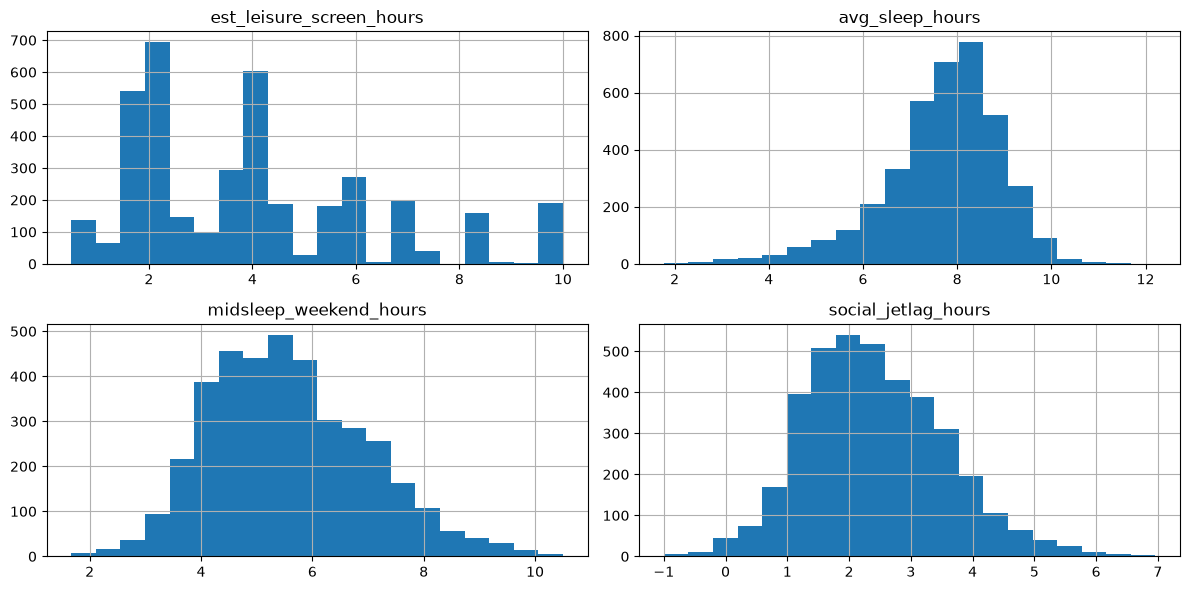

In [12]:
cols_to_check = ["est_leisure_screen_hours", "avg_sleep_hours",
                  "midsleep_weekend_hours", "social_jetlag_hours"]

print(X_train[cols_to_check].describe())

print("\nFive largest est_leisure_screen_hours:")
print(X_train["est_leisure_screen_hours"].nlargest(5))

print("\nFive smallest avg_sleep_hours:")
print(X_train["avg_sleep_hours"].nsmallest(5))

X_train[cols_to_check].hist(bins=20, figsize=(12, 6))
plt.tight_layout()
plt.show()

---
###
**`est_leisure_screen_hours`**

The maximum is exactly 10.0, and the five largest values are all tied at 10.0 — a pattern that suggests a capped or clipped measurement rather than organic behaviour, likely a "10+ hours" ceiling in the survey instrument. This is a measurement limitation to note, not an error to remove; deleting these rows would eliminate real heavy screen-time users, which works against the research question.

**`avg_sleep_hours`**

The five smallest values (1.77 to 2.49 hours) are unusual but pass the valid range check (0–24) established earlier. Very short average sleep is rare but documented among adolescents in self-reported sleep data. Given the research question centres on the sleep–depression relationship, these cases may be some of the most theoretically important rows in the dataset — removing them would cut out the extreme end of exactly the relationship under study.

**`social_jetlag_hours`**

A minimum of -1.00 in this training subset is consistent with the earlier full-dataset finding of legitimate negative social jetlag (sleeping earlier on weekends than weekdays), a real phenomenon rather than an error.

**`midsleep_weekend_hours`**

Nothing unusual — the distribution looks evenly spread with no flags.

**Decision: keep all values**

None of these values are impossible; they passed the Section 2 range checks and each has a plausible explanation rooted in either measurement design or genuine behavioural variation. Since the research question concerns whether these variables predict depression risk, the extreme values carry signal rather than noise, and removing them would shrink the sample while biasing the model against participants at the edges of the screen-time and sleep-quality spectrum.

One point worth flagging in the writeup: the ceiling effect at 10.0 for `est_leisure_screen_hours` is a genuine data limitation, since it's impossible to distinguish "reports exactly 10 hours" from "reports 10+ hours, capped by the survey design."

---
## 7. Dates

In [13]:
# Section 7 does not apply to this dataset.
# Neither BDI.csv nor Mental_health.csv contains a date or timestamp column,
# so there is no field to parse or extract date-based features from.
print("No date column present in this dataset — Section 7 skipped.")

No date column present in this dataset — Section 7 skipped.


---
## 8. Feature engineering

Create **at least two new features** that could plausibly help predict satisfaction. Write one sentence per feature explaining why.

Ideas: income per household member, age group, purchases per online hour.

**Why here, before encoding and scaling?** A ratio of two *scaled* variables is meaningless — engineer features from the original units.

In [14]:
# Feature 1: weekend vs weekday screen-time gap
# Rationale: a large gap may indicate compensatory or binge screen use on weekends,
# which raw weekday/weekend values alone don't directly capture.
X_train["screen_weekend_weekday_gap"] = X_train["screen_weekend_1to6"] - X_train["screen_weekday_1to6"]
X_test["screen_weekend_weekday_gap"] = X_test["screen_weekend_1to6"] - X_test["screen_weekday_1to6"]

# Feature 2: composite sleep disturbance score
# Rationale: averaging the four individual sleep-quality-index items into one score
# summarises overall sleep disturbance, which may relate more directly to depression
# risk than any single item alone.
sleep_disturbance_cols = ["sqi_fall_asleep_1to6", "sqi_repeated_awake_1to6",
                           "sqi_disturbed_1to6", "sqi_early_awake_1to6"]
X_train["sleep_disturbance_composite"] = X_train[sleep_disturbance_cols].mean(axis=1)
X_test["sleep_disturbance_composite"] = X_test[sleep_disturbance_cols].mean(axis=1)

print(X_train[["screen_weekend_weekday_gap", "sleep_disturbance_composite"]].describe())

       screen_weekend_weekday_gap  sleep_disturbance_composite
count                 3848.000000                  3848.000000
mean                     0.729990                     1.894880
std                      0.947334                     0.850003
min                     -5.000000                     1.000000
25%                      0.000000                     1.250000
50%                      1.000000                     1.750000
75%                      1.000000                     2.250000
max                      5.000000                     6.000000


---

## **`screen_weekend_weekday_gap`**

The mean is about 0.73, meaning the typical adolescent reports somewhat higher screen time on weekends than weekdays. The range runs from -5 to +5, since the underlying scales are each 1–6, so this is the full theoretical range of the difference — nothing impossible here. A median of 1 and 75th percentile also at 1 shows the gap is modest for most of the sample, with a smaller number of adolescents showing a much larger weekend increase (up to +5) or, less commonly, more weekday screen time (down to -5).

## **`sleep_disturbance_composite`**

The mean is about 1.89, on the same 1–6 scale as its four source items, sitting toward the lower-disturbance end of the range. The minimum of exactly 1.0 makes sense — it occurs when all four sleep-disturbance items are at their own minimum. The maximum of 6.0 similarly reflects all four items at their own maximum. Quartiles spread from 1.25 to 2.25, suggesting most of the sample reports relatively low sleep disturbance, with a right-skewed tail toward more disturbed sleepers.

## **What this means for the two features**

Neither shows impossible or clearly erroneous values — both sit within the ranges their construction guarantees. This is a reasonable checkpoint to note in the notebook before moving to Section 10 (scaling), since these are exactly the kind of ratio/difference features the section instructions warn should be built from original units first, which is what happened here.

---
## 9. Encoding categorical variables

In [15]:
# Section 9 does not apply to this feature set.
# All features (screen-time and sleep-quality variables, plus the two engineered
# features from Section 8) are numeric. No nominal or ordinal categorical variable
# was included as a feature — 'sex' was deliberately excluded in Section 3, as it
# falls outside the stated research question (predicting depression from screen
# time and sleep quality alone). There is therefore nothing to encode.
print("No categorical features present — Section 9 skipped.")

No categorical features present — Section 9 skipped.


---
## 10. Scaling numerical variables

In [16]:
numeric_cols = X_train.columns.tolist()  # all columns are numeric

print("Ranges before scaling:")
print(X_train[numeric_cols].agg(["min", "max"]).T)

scaler = StandardScaler()

# Learn mean and std from TRAINING data only.
scaler.fit(X_train[numeric_cols])

# Apply those same training-learned values to both sets.
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("\nTraining data after scaling (should be ~mean 0, std 1):")
print(X_train_scaled[numeric_cols].agg(["mean", "std"]).T)

Ranges before scaling:
                              min    max
screen_normal_day_1to6       1.00   6.00
screen_weekday_1to6          1.00   6.00
screen_weekend_1to6          1.00   6.00
screen_time_index            1.00   6.00
est_leisure_screen_hours     0.50  10.00
sqi_fall_asleep_1to6         1.00   6.00
sqi_repeated_awake_1to6      1.00   6.00
sqi_disturbed_1to6           1.00   6.00
sqi_early_awake_1to6         1.00   6.00
sleep_quality_index          1.00   6.00
avg_sleep_hours              1.77  12.21
midsleep_weekend_hours       1.67  10.50
social_jetlag_hours         -1.00   6.96
screen_weekend_weekday_gap  -5.00   5.00
sleep_disturbance_composite  1.00   6.00

Training data after scaling (should be ~mean 0, std 1):
                                     mean      std
screen_normal_day_1to6       1.661872e-16  1.00013
screen_weekday_1to6          7.201447e-17  1.00013
screen_weekend_1to6         -1.698803e-16  1.00013
screen_time_index           -3.471467e-16  1.00013
est_leisu

**Answer:**

**Before scaling**

The ranges confirm exactly the mismatch the section describes: most columns run 1–6 (the survey rating scales), while `est_leisure_screen_hours` runs 0.5–10, `avg_sleep_hours` runs 1.77–12.21, `midsleep_weekend_hours` runs 1.67–10.5, and `screen_weekend_weekday_gap` runs -5 to 5. Without scaling, a model using distances or gradients (like k-NN or logistic regression with regularisation) could treat `avg_sleep_hours` as inherently more important than `sqi_fall_asleep_1to6`, simply because its raw numbers are larger — not because it's actually more predictive.

**After scaling**

Every column's mean is now effectively 0 — the values shown (like `1.66e-16`) are floating-point rounding artifacts of true zero, not meaningful deviations. Every column's standard deviation is 1.00013, which rounds to 1 (the tiny excess above exactly 1.0 is `StandardScaler`'s use of `n` rather than `n-1` in its variance calculation combined with floating-point precision — not an error).

**What this confirms**

Standardisation worked correctly: all 15 features, regardless of their original units or ranges, are now on a common scale centred at 0 with unit variance. This means each feature's contribution to a downstream model reflects its actual relationship with the target, not an artifact of its original measurement scale. Since `X_train_scaled` was fit only on training data, this transformation is safe to now apply identically to `X_test_scaled` without any information leaking from the test set.


---
## 11. Doing the same preparation with a pipeline

So far, we have prepared the data one step at a time: fill missing values, extract date information, create new features, encode categories, and scale numeric columns.

A **pipeline** is simply a saved checklist of those steps. Instead of writing and running each step separately every time, we put the steps in the correct order once and ask Python to run that checklist for us.

For this notebook, the pipeline does the following:

1. Starts with the original training or test table.
2. Extracts month and day of week from `survey_date` and creates the two ratio features.
3. Fills missing numeric values, then standardises numeric columns.
4. Fills and encodes `education` in its meaningful order.
5. Fills and turns `gender` and `age_group` into 0/1 columns.

When we run `fit_transform(X_train)`, the pipeline learns any required values, such as medians and category lists, from the training data and prepares it. When we run `transform(X_test)`, it follows the exact same checklist for the test data but reuses the values learned from training.

This keeps our preparation consistent and prevents us from accidentally learning from the test data. It is still only data preparation; we are not building a predictive model yet.

In [ ]:
def row_wise_features(data):
    """Create features using each row only; no dataset-wide values are learned here."""
    result = data.copy()

    # Turn one date column into two numeric calendar features.
    dates = pd.to_datetime(result["survey_date"], errors="coerce")
    result["survey_month"] = dates.dt.month
    result["survey_dayofweek"] = dates.dt.dayofweek

    # Create ratios before scaling, while values still use their original units.
    result["income_per_person"] = (
        result["annual_income_eur"] / result["household_size"].clip(lower=1)
    )
    result["purchases_per_online_hour"] = (
        result["online_purchases_last_month"] / result["hours_online_per_week"].clip(lower=0.1)
    )

    # Keep age bands as categories; the nominal pipeline will encode them.
    result["age_group"] = pd.cut(
        result["age"], bins=[0, 29, 44, 64, np.inf],
        labels=["18-29", "30-44", "45-64", "65+"],
    ).astype("object")
    return result.drop(columns="survey_date")

# Assign each column to the type of preprocessing it needs.
numeric_cols = [
    "age", "household_size", "annual_income_eur", "hours_online_per_week",
    "online_purchases_last_month", "survey_month", "survey_dayofweek",
    "income_per_person", "purchases_per_online_hour",
]
ordinal_cols = ["education"]
nominal_cols = ["gender", "age_group"]
edu_order = ["High School", "Bachelor", "Master", "PhD"]

# For numeric data: fill gaps with training medians, then put columns on a common scale.
numeric_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

# For education: fill gaps, then encode the supplied meaningful order.
ordinal_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OrdinalEncoder(categories=[edu_order])),
])

# For nominal data: label missing values and create a 0/1 column for each category.
nominal_pipeline = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encode", OneHotEncoder(handle_unknown="ignore")),
])

# Send each group of columns through its appropriate mini-pipeline.
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("ord", ordinal_pipeline, ordinal_cols),
    ("nom", nominal_pipeline, nominal_cols),
])

# First create features, then preprocess the resulting columns.
preprocessing_pipeline = Pipeline([
    ("features", FunctionTransformer(row_wise_features)),
    ("preprocess", preprocessor),
])

# fit_transform learns every required value from the training data and transforms it.
X_train_prepared = preprocessing_pipeline.fit_transform(X_train)

# transform applies those already-learned values to the unseen test data.
X_test_prepared = preprocessing_pipeline.transform(X_test)
print("Prepared train shape:", X_train_prepared.shape)
print("Prepared test shape: ", X_test_prepared.shape)

Prepared train shape: (480, 20)
Prepared test shape:  (120, 20)


### Check your preprocessing output

After completing the scaffold, inspect the transformed arrays or dataframe:

- How many rows and columns are there now?
- Are there any missing values left?
- Which original categorical columns became several binary columns?
- Which values were learned from `X_train`, rather than from the full dataset?

There is no model training or model score in this notebook; those belong to Week 5.

---
## 12. Leakage, revisited

### 12a. Preprocessing leakage

**Question:** should imputation medians and scaling parameters be calculated on the entire dataset before splitting?

Use the output below to compare the values. Then explain in 2–3 sentences why the training-only version is the correct workflow.

The difference may be small in this dataset. The important issue is whether the test set influenced a decision before evaluation.

### 12b. Target leakage

`complaint_filed_after_survey` is recorded after the survey. Should it be available as an input when predicting satisfaction at survey time?

Explain:

1. When is this column known?
2. When would the prediction be made?
3. Why can a train/test split fail to reveal this kind of leakage?

In [ ]:
col = "annual_income_eur"
print(f"median from ALL data   : {X[col].median():>10,.0f}")
print(f"median from TRAIN only : {X_train[col].median():>10,.0f}")
print(f"mean   from ALL data   : {X[col].mean():>10,.0f}")
print(f"mean   from TRAIN only : {X_train[col].mean():>10,.0f}")

median from ALL data   :     51,300
median from TRAIN only :     51,200
mean   from ALL data   :     58,834
mean   from TRAIN only :     58,998


A train/test split cannot reliably catch target leakage: the leaked column can appear in both splits. The problem appears when the system is used in practice, because at prediction time the complaint has not been filed yet.

*Always ask: would this feature be available before the outcome is known?*

---
# Exit ticket

1. Why are the median, category mappings, and scaling values learned from `X_train` rather than the full dataset?
2. Why is `complaint_filed_after_survey` target leakage when predicting `satisfaction_score` at survey time?